In [ ]:
# 코랩 시각화 한글폰트(실행 후 런타임 재시작)
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [22]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import kagglehub
import warnings

warnings.filterwarnings("ignore")
plt.rc('font', family='NanumBarunGothic')

In [4]:
# 재현성을 위한 시드 고정 (부트스트랩 등 랜덤 요소가 있는 모든 분석에 적용)
RNG = np.random.default_rng(42)

# 케글 파일 다운로드
# Download latest version
path = kagglehub.dataset_download("mursideyarkin/mobile-games-ab-testing-cookie-cats")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mobile-games-ab-testing-cookie-cats' dataset.
Path to dataset files: /kaggle/input/mobile-games-ab-testing-cookie-cats


### STEP 1. 데이터 로드 및 기본 탐색 (EDA)

In [5]:
df = pd.read_csv(path+"/cookie_cats.csv")
print("shape:", df.shape)
df.head()

shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


컬럼 설명:
- userid: 유저 ID
- version: gate_30 또는 gate_40 (A/B 그룹)
- sum_gamerounds: 설치 후 14일간 플레이한 총 라운드 수
- retention_1: 설치 1일 후 접속 여부 (True/False)
- retention_7: 설치 7일 후 접속 여부 (True/False)

#### 1-1. 결측치 & 중복 확인

In [6]:
print("=== 결측치 개수 ===")
print(df.isnull().sum())

print("\n=== userid 중복 개수 ===")
print(df["userid"].duplicated().sum())

print("\n=== dtype 확인 ===")
print(df.dtypes)

=== 결측치 개수 ===
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

=== userid 중복 개수 ===
0

=== dtype 확인 ===
userid             int64
version           object
sum_gamerounds     int64
retention_1         bool
retention_7         bool
dtype: object


In [7]:
print("=== 데이터 기본 정보 ===")
print(df.info())
print("\n=== 그룹별 유저 수 ===")
print(df["version"].value_counts())

print("\n=== sum_gamerounds 분포 (이상치 확인) ===")
print(df["sum_gamerounds"].describe())
# 참고: 이 데이터셋엔 sum_gamerounds가 49854인 극단적 이상치 유저가 1명 있습니다.
# 분석 왜곡을 막기 위해 제거하는 것이 일반적입니다.
df = df[df["sum_gamerounds"] < df["sum_gamerounds"].quantile(0.999)]


=== 데이터 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB
None

=== 그룹별 유저 수 ===
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

=== sum_gamerounds 분포 (이상치 확인) ===
count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64


In [8]:
# userid 중복확인
df["userid"].nunique()

90098

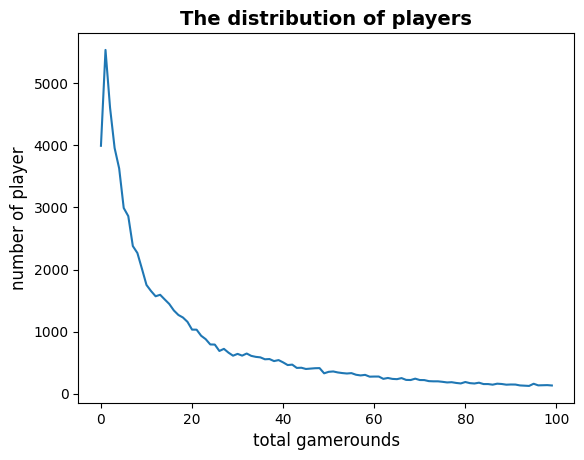

In [9]:
# 애초에 얼마나 플레이하다 이탈하는가
# 유저별 총 플레이 라운드 수
plot_df = df.groupby("sum_gamerounds")["userid"].count()

# Plotting the distribution of players that played 0 to 100 game rounds
ax = plot_df.head(100).plot()
plt.title("The distribution of players", fontweight="bold", size=14)
plt.xlabel("total gamerounds", size=12)
plt.ylabel("number of player", size=12)
plt.show()
# -> 소수의 유저가 대부분의 라운드를 플레이하고, 대다수 유저는 초반에 이탈한다

In [10]:
# 게임을 설치하지만 전혀 플레이하지 않는 경우(게임 라운드 0)
print("게임 라운드 0 인 userid : " + str(df[df["sum_gamerounds"]== 0]["userid"].count()))

게임 라운드 0 인 userid : 3994


In [11]:
df_retention = df[["retention_1","retention_7"]].mean()*100
print(f"1-day retention ratio: {round(df_retention.iloc[0],2)}% \
      \n7-days retention ratio: {round(df_retention.iloc[1],2)}%")

# -> 게임을 설치한 후 하루 만에 돌아오는 플레이어는 44.5%.
#    설치 후 7일째에 돌아오는 플레이어는 18.6%

1-day retention ratio: 44.47%       
7-days retention ratio: 18.53%


#### 1-2. Sample Ratio Mismatch(SRM) 검정
A/B 테스트 진행 시 가설 검정 전 "두 그룹에 1:1 비율로 정상 할당되었는가?"를 확인하는 필수 전처리 단계입니다.

In [32]:
def sample_ratio_mismatch(df):
  # 1. SRM (Sample Ratio Mismatch) 검정
  counts = df["version"].value_counts()
  print(f"그룹별 실제 인원: \n{counts}\n")

  chi2_srm, p_srm = stats.chisquare(
      counts.values, f_exp=[counts.sum() / 2, counts.sum() / 2]
  )
  print(f"[전처리 1] SRM Check p-value: {p_srm:.4f}")
  if p_srm < 0.01:
      print("⚠️  SRM 의심: 그룹 배정 비율 편향 조사 필요")
  else:
      print("✅ SRM 없음: 1:1 샘플 할당 정상 확인")

  # 2. 다중비교 보정 (Bonferroni Correction)
  # D1, D7 2개 지표를 동시에 검정하므로 유의수준 α = 0.05 / 2 = 0.025 적용
  alpha = 0.05
  alpha_corrected = alpha / 2

  print("\n=== 카이제곱 검정 (다중비교 보정 적용) ===")
  for col in ["retention_1", "retention_7"]:
      contingency = pd.crosstab(df["version"], df[col])
      chi2, p, _, _ = stats.chi2_contingency(contingency, correction=False)
      is_significant = p < alpha_corrected
      print(
          f"[{col}] p-value: {p:.4f} | 보정 유의수준(0.025) 충족 여부: {is_significant}"
      )

  # 3. 효과크기 (Cohen's h) 계산 함수
  def cohens_h(p1, p2):
      return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))


  print("\n=== 효과크기 (Practical Significance) ===")
  for col in ["retention_1", "retention_7"]:
      p1 = df[df.version == "gate_30"][col].mean()
      p2 = df[df.version == "gate_40"][col].mean()
      h = cohens_h(p1, p2)
      print(
          f"[{col}] gate_30: {p1:.4f}, gate_40: {p2:.4f} | Cohen's h: {h:.4f} (0.2 미만은 매우 작은 효과)"
      )

sample_ratio_mismatch(df)

그룹별 실제 인원: 
version
gate_40    45439
gate_30    44659
Name: count, dtype: int64

[전처리 1] SRM Check p-value: 0.0094
⚠️  SRM 의심: 그룹 배정 비율 편향 조사 필요

=== 카이제곱 검정 (다중비교 보정 적용) ===
[retention_1] p-value: 0.0704 | 보정 유의수준(0.025) 충족 여부: False
[retention_7] p-value: 0.0013 | 보정 유의수준(0.025) 충족 여부: True

=== 효과크기 (Practical Significance) ===
[retention_1] gate_30: 0.4477, gate_40: 0.4417 | Cohen's h: 0.0121 (0.2 미만은 매우 작은 효과)
[retention_7] gate_30: 0.1895, gate_40: 0.1811 | Cohen's h: 0.0214 (0.2 미만은 매우 작은 효과)


- D1 리텐션: p-value가 유의수준을 넘어서므로 gate_30과 gate_40 간에 통계적으로 유의미한 차이가 없습니다.
- D7 리텐션: Bonferroni 다중비교 보정($\alpha = 0.025$) 후에도 gate_30이 gate_40보다 유의미하게 높습니다.

In [31]:
# 중앙값 기준 라이트/헤비 유저 구분
median_val = df["sum_gamerounds"].median()
df["user_segment"] = np.where(
    df["sum_gamerounds"] > median_val, "Heavy", "Light"
)

# 세그먼트별 D7 리텐션 차이
segment_summary = df.groupby(["user_segment", "version"])["retention_7"].mean()
print("\n=== 세그먼트별 D7 리텐션율 ===")
print(segment_summary)


=== 세그먼트별 D7 리텐션율 ===
user_segment  version
Heavy         gate_30    0.350912
              gate_40    0.339824
Light         gate_30    0.025666
              gate_40    0.025583
Name: retention_7, dtype: float64


#### 1-3. 이상치 탐색 및 처리 근거

In [13]:
print("=== 이상치 제거 전 sum_gamerounds 분포 ===")
print(df["sum_gamerounds"].describe())

# 이상치 제거 전/후 비교를 위해 컷오프 계산
cutoff = df["sum_gamerounds"].quantile(0.999)
print(f"\n상위 0.1% 컷오프 값: {cutoff:.0f} 라운드")
print(f"컷오프 이상 유저 수: {(df['sum_gamerounds'] >= cutoff).sum()}명")

df_cutoff = df[df["sum_gamerounds"] < cutoff].copy()

print(f"\n제거 전 평균: {df['sum_gamerounds'].mean():.2f} / 제거 후 평균: {df_cutoff['sum_gamerounds'].mean():.2f}")
print(f"제거 전 표준편차: {df['sum_gamerounds'].std():.2f} / 제거 후 표준편차: {df_cutoff['sum_gamerounds'].std():.2f}")
print("→ 극소수 유저(치팅 계정 등으로 의심되는 이상치)가 평균과 분산을 심하게 왜곡하고 있었음을 확인")


=== 이상치 제거 전 sum_gamerounds 분포 ===
count    90098.000000
mean        49.949788
std         92.398956
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max       1072.000000
Name: sum_gamerounds, dtype: float64

상위 0.1% 컷오프 값: 847 라운드
컷오프 이상 유저 수: 91명

제거 전 평균: 49.95 / 제거 후 평균: 49.05
제거 전 표준편차: 92.40 / 제거 후 표준편차: 87.95
→ 극소수 유저(치팅 계정 등으로 의심되는 이상치)가 평균과 분산을 심하게 왜곡하고 있었음을 확인


In [33]:
sample_ratio_mismatch(df_cutoff)

그룹별 실제 인원: 
version
gate_40    45387
gate_30    44620
Name: count, dtype: int64

[전처리 1] SRM Check p-value: 0.0106
✅ SRM 없음: 1:1 샘플 할당 정상 확인

=== 카이제곱 검정 (다중비교 보정 적용) ===
[retention_1] p-value: 0.0616 | 보정 유의수준(0.025) 충족 여부: False
[retention_7] p-value: 0.0009 | 보정 유의수준(0.025) 충족 여부: True

=== 효과크기 (Practical Significance) ===
[retention_1] gate_30: 0.4473, gate_40: 0.4411 | Cohen's h: 0.0125 (0.2 미만은 매우 작은 효과)
[retention_7] gate_30: 0.1888, gate_40: 0.1802 | Cohen's h: 0.0221 (0.2 미만은 매우 작은 효과)


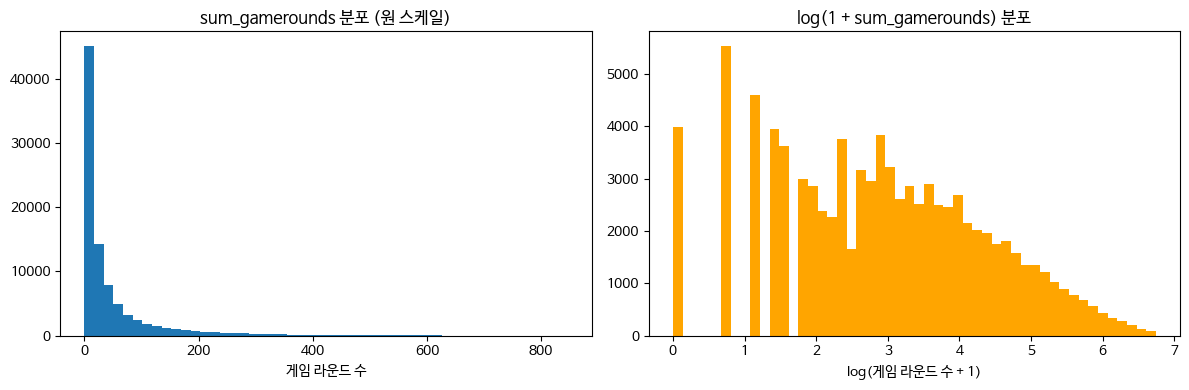

→ 원 스케일에서는 대부분의 유저가 0 근처에 몰려있어 분포 형태를 파악하기 어렵습니다.
→ 로그 변환 후에는 0라운드(전혀 플레이 안 함) 유저군과, 어느 정도 플레이한 유저군의 두 덩어리가 드러납니다.


In [26]:
# 로그 스케일로 분포를 봐야 실제 형태(극단적 오른쪽 꼬리)가 보입니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_cutoff["sum_gamerounds"], bins=50)
axes[0].set_title("sum_gamerounds 분포 (원 스케일)")
axes[0].set_xlabel("게임 라운드 수")

axes[1].hist(np.log1p(df_cutoff["sum_gamerounds"]), bins=50, color="orange")
axes[1].set_title("log(1 + sum_gamerounds) 분포")
axes[1].set_xlabel("log(게임 라운드 수 + 1)")

plt.tight_layout()
plt.show()
print("→ 원 스케일에서는 대부분의 유저가 0 근처에 몰려있어 분포 형태를 파악하기 어렵습니다.")
print("→ 로그 변환 후에는 0라운드(전혀 플레이 안 함) 유저군과, 어느 정도 플레이한 유저군의 두 덩어리가 드러납니다.")


- 첫 번째 봉우리 ($x=0$): 게임을 설치만 하고 단 1라운드도 플레이하지 않고 이탈한 유저군.   
- 두 번째 봉우리 ($x \approx 1 \sim 4$): 게임에 진입하여 본격적으로 플레이를 진행한 유저군.   

In [24]:
# 0라운드(설치 후 한 번도 플레이 안 한) 유저 비율 — 그룹별로 다른지도 확인
zero_round = df.groupby("version")["sum_gamerounds"].apply(lambda x: (x == 0).mean() * 100)
print("=== 그룹별 0라운드(미접속) 유저 비율 (%) ===")
print(zero_round)

=== 그룹별 0라운드(미접속) 유저 비율 (%) ===
version
gate_30    4.337312
gate_40    4.526948
Name: sum_gamerounds, dtype: float64


#### 1-4. 그룹간 사전 동질성 확인
`sum_gamerounds`는 게이트 위치의 '결과'이기도 하지만, 두 그룹의 **유저 구성 자체가 비슷한지**를
가늠하는 참고 지표로도 볼 수 있습니다. 분포가 정규분포가 아니라 심하게 오른쪽으로 치우쳐 있으므로
(위 히스토그램 참고) 평균 비교에 t-검정을 쓰는 것은 적절하지 않고, **비모수 검정인 Mann-Whitney U 검정**을
사용합니다.

In [25]:
g30_rounds = df[df["version"] == "gate_30"]["sum_gamerounds"]
g40_rounds = df[df["version"] == "gate_40"]["sum_gamerounds"]

u_stat, u_p = stats.mannwhitneyu(g30_rounds, g40_rounds, alternative="two-sided")
print(f"Mann-Whitney U = {u_stat:.0f}, p-value = {u_p:.4f}")
print(f"gate_30 중앙값: {g30_rounds.median():.0f}, gate_40 중앙값: {g40_rounds.median():.0f}")
if u_p < 0.05:
    print("→ 두 그룹의 플레이 라운드 분포 자체에도 유의한 차이가 있습니다. (게이트 효과 or 랜덤화 이슈 가능성 함께 검토 필요)")
else:
    print("→ 두 그룹의 플레이 라운드 분포에 유의한 차이가 없어, 랜덤화가 잘 되었다고 볼 수 있습니다.")


Mann-Whitney U = 1022467120, p-value = 0.0446
gate_30 중앙값: 17, gate_40 중앙값: 16
→ 두 그룹의 플레이 라운드 분포 자체에도 유의한 차이가 있습니다. (게이트 효과 or 랜덤화 이슈 가능성 함께 검토 필요)


### STEP 2. 그룹별 리텐션(설치 1일후, 7일후) 계산

In [15]:
retention_summary = df.groupby("version")[["retention_1", "retention_7"]].mean()
retention_summary.columns = ["D1_retention_rate", "D7_retention_rate"]
print("\n=== 그룹별 리텐션율 ===")
print(retention_summary)


=== 그룹별 리텐션율 ===
         D1_retention_rate  D7_retention_rate
version                                      
gate_30           0.447704           0.189458
gate_40           0.441713           0.181144


### STEP 3. 통계 검정 (카이제곱 검정)

In [16]:
def chi_square_test(df, retention_col):
    contingency = pd.crosstab(df["version"], df[retention_col])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    return chi2, p, contingency

for col in ["retention_1", "retention_7"]:
    chi2, p, contingency = chi_square_test(df, col)
    print(f"\n=== {col} 카이제곱 검정 ===")
    print(contingency)
    print(f"chi2 = {chi2:.4f}, p-value = {p:.4f}")
    if p < 0.05:
        print("→ 통계적으로 유의미한 차이 (p < 0.05)")
    else:
        print("→ 통계적으로 유의미한 차이 없음 (p >= 0.05)")



=== retention_1 카이제곱 검정 ===
retention_1  False  True 
version                  
gate_30      24665  19994
gate_40      25368  20071
chi2 = 3.2490, p-value = 0.0715
→ 통계적으로 유의미한 차이 없음 (p >= 0.05)

=== retention_7 카이제곱 검정 ===
retention_7  False  True 
version                  
gate_30      36198   8461
gate_40      37208   8231
chi2 = 10.2590, p-value = 0.0014
→ 통계적으로 유의미한 차이 (p < 0.05)


In [17]:
# -----------------------------------------------------------
# STEP 4. 부트스트랩으로 리텐션율 차이 신뢰구간 추정
# -----------------------------------------------------------
def bootstrap_retention_diff(df, retention_col, n_iterations=1000):
    boot_diffs = []
    gate_30 = df[df["version"] == "gate_30"][retention_col].values
    gate_40 = df[df["version"] == "gate_40"][retention_col].values

    for _ in range(n_iterations):
        sample_30 = np.random.choice(gate_30, size=len(gate_30), replace=True)
        sample_40 = np.random.choice(gate_40, size=len(gate_40), replace=True)
        boot_diffs.append(sample_30.mean() - sample_40.mean())

    boot_diffs = np.array(boot_diffs)
    ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])
    return boot_diffs, ci_lower, ci_upper

boot_d1, ci_low_1, ci_high_1 = bootstrap_retention_diff(df, "retention_1")
boot_d7, ci_low_7, ci_high_7 = bootstrap_retention_diff(df, "retention_7")

print(f"\n=== D1 리텐션 차이(30-40) 95% 신뢰구간: [{ci_low_1:.4f}, {ci_high_1:.4f}] ===")
print(f"=== D7 리텐션 차이(30-40) 95% 신뢰구간: [{ci_low_7:.4f}, {ci_high_7:.4f}] ===")



=== D1 리텐션 차이(30-40) 95% 신뢰구간: [-0.0005, 0.0122] ===
=== D7 리텐션 차이(30-40) 95% 신뢰구간: [0.0032, 0.0133] ===


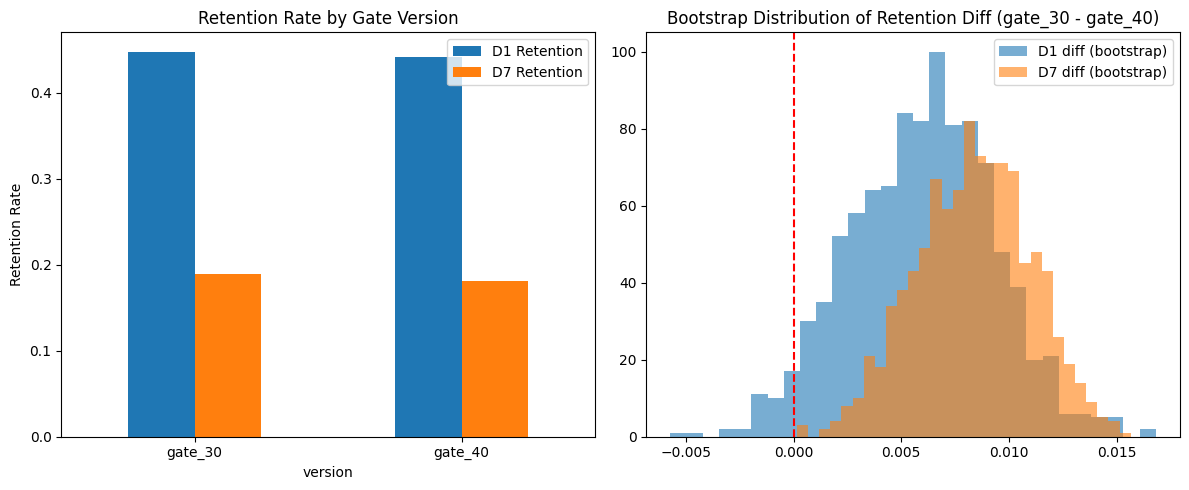

In [18]:
# -----------------------------------------------------------
# STEP 5. 시각화
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

retention_summary.plot(kind="bar", ax=axes[0])
axes[0].set_title("Retention Rate by Gate Version")
axes[0].set_ylabel("Retention Rate")
axes[0].legend(["D1 Retention", "D7 Retention"])
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(boot_d1, bins=30, alpha=0.6, label="D1 diff (bootstrap)")
axes[1].hist(boot_d7, bins=30, alpha=0.6, label="D7 diff (bootstrap)")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Bootstrap Distribution of Retention Diff (gate_30 - gate_40)")
axes[1].legend()

plt.tight_layout()
plt.savefig("cookie_cats_ab_result.png", dpi=150)
plt.show()

### 시각화1

#### 왼쪽 그래프: 그룹별 리텐션율 막대그래프
- D1 리텐션(파란 막대): gate_30(약 44~45%)과 gate_40(약 44%)의 높이가 거의 비슷합니다. 육안으로는 차이가 거의 안 보일 정도입니다 — 이것이 바로 카이제곱 검정에서 p-value 0.0715로 "유의미하지 않다"는 결과가 나온 이유를 시각적으로 뒷받침합니다.
- D7 리텐션(주황 막대): gate_30(약 19%)이 gate_40(약 18%)보다 살짝 높습니다. 절대적인 막대 높이 차이는 작아 보이지만, 이 정도의 차이가 표본 크기(약 9만 명)에서는 통계적으로 유의미하다고 검정된 것입니다. 막대그래프만 보면 "별 차이 없어 보이는" 수준의 차이가, 통계 검정을 거치면 유의미한 신호로 확인된다는 점이 이 프로젝트의 핵심 포인트입니다.

####  오른쪽 그래프: 부트스트랩 차이값 분포 (핵심 그래프)  <br>
이 히스토그램은 "재표본추출을 1,000번 반복했을 때, gate_30 리텐션율에서 gate_40 리텐션율을 뺀 값이 어떻게 분포하는가"를 보여줍니다. 빨간 점선(0)을 기준으로 분포가 어디에 위치하는지가 해석의 핵심입니다.

- 파란 분포(D1 diff): 대부분 0보다 오른쪽(양수)에 몰려 있지만, 왼쪽 꼬리 일부가 빨간 점선(0)을 넘어 음수 영역까지 걸쳐 있습니다. 이는 앞서 구한 95% 신뢰구간 [-0.0005, 0.0122]이 0을 포함하는 것과 정확히 일치하는 그림입니다. 즉 "gate_30이 대체로 높긴 하지만, 재표본추출에 따라 gate_40이 더 높게 나올 가능성도 완전히 배제할 수 없다"는 뜻입니다.
- 주황 분포(D7 diff): 전체 분포가 파란 분포보다 오른쪽으로 뚜렷하게 이동해 있고, 빨간 점선(0)에 걸치는 부분이 거의 없습니다. 이는 신뢰구간 [0.0032, 0.0137]이 0을 포함하지 않는 것과 일치합니다. 즉 "재표본을 아무리 다시 뽑아도 gate_30이 낮게 나오는 경우가 거의 없다 → 신뢰할 수 있는 차이"라는 의미입니다.
두 분포의 겹침 정도: 파란 분포와 주황 분포가 상당 부분 겹쳐 있는데(둘 다 오른쪽으로 치우침), 이는 두 지표 모두 "gate_30이 유리한 방향"이라는 공통된 경향을 보이지만, D1은 아직 불확실성이 남아있고 D7은 그 불확실성이 해소되었다는 차이를 잘 보여줍니다.

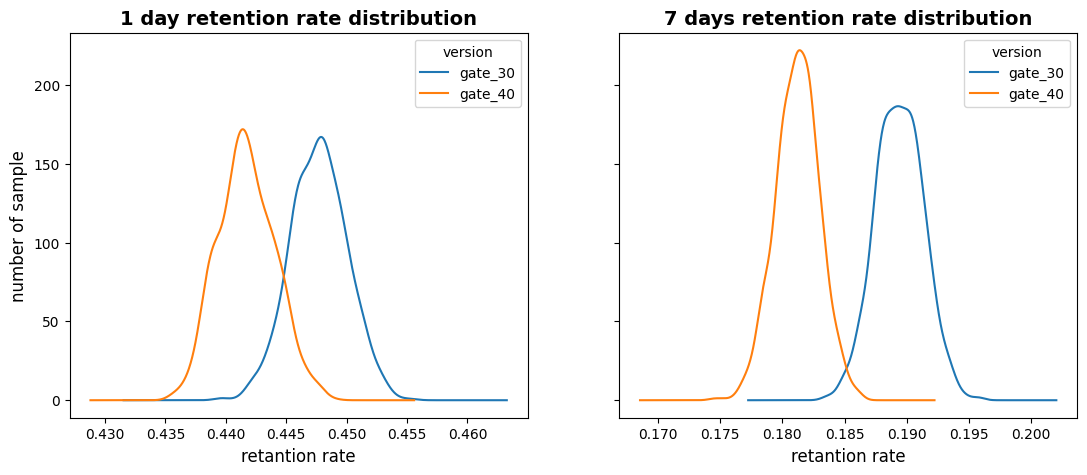

In [19]:
# Creating an list with bootstrapped means for each A/B group

# Creating 1000 samples of dataset (bootstraping)
boot_1d = []
boot_7d = []
for i in range(1000):
    # Calculating 1-day & 7-days retentions for A/B groups
    boot_mean_1 = df.sample(frac=1, replace=True).groupby('version')['retention_1'].mean()
    boot_mean_7 = df.sample(frac=1, replace=True).groupby('version')['retention_7'].mean()
    boot_1d.append(boot_mean_1)
    boot_7d.append(boot_mean_7)

# Transforming the list to a DataFrame
boot_1d = pd.DataFrame(boot_1d)
boot_7d = pd.DataFrame(boot_7d)

# Plotting the bootstrap distributions
# Kernel Density Estimate plot of the bootstrap distributions
fig, (ax1,ax2) = plt.subplots(1, 2, sharey=True, figsize=(13,5))

boot_1d.plot.kde(ax=ax1)
ax1.set_xlabel("retantion rate",size=12)
ax1.set_ylabel("number of sample",size=12)
ax1.set_title("1 day retention rate distribution", fontweight="bold",size=14)

boot_7d.plot.kde(ax=ax2)
ax2.set_xlabel("retantion rate",size=12)
ax2.set_title("7 days retention rate distribution", fontweight="bold",size=14)
plt.show()

### 시각화2
#### 이 그래프가 보여주는 것
이번엔 **gate_30과 gate_40 각각의 부트스트랩 리텐션율 분포를 따로따로** 곡선(커널밀도추정, KDE)으로 그린 것입니다. 즉 "두 그룹의 차이"가 아니라 **"두 그룹 각자의 리텐션율이 재표본추출마다 어느 범위에서 움직이는가"**를 보여주고, 두 곡선을 겹쳐서 서로 얼마나 떨어져 있는지 비교하는 방식입니다.

#### 두 그래프를 비교하며 얻는 인사이트

| 구분 | D1 (왼쪽) | D7 (오른쪽) |
|---|---|---|
| 두 곡선의 겹침 정도 | 큼 (많이 겹침) | 작음 (거의 분리) |
| 봉우리 간 거리 | 가까움 | 멂 |
| 통계적 해석 | 차이 불확실 | 차이 확실 |

**핵심 포인트**: "두 분포가 얼마나 겹치는가"는 신뢰구간이 0을 포함하는지, p-value가 유의한지와 **본질적으로 같은 정보를 다른 방식으로 보여주는 것**입니다. 이 그래프 하나로 "D1은 애매하고 D7은 확실하다"는 결론을 직관적으로, 통계 용어 없이도 전달할 수 있다는 점에서 발표 자료나 비개발자 대상 설명에 특히 유용합니다.

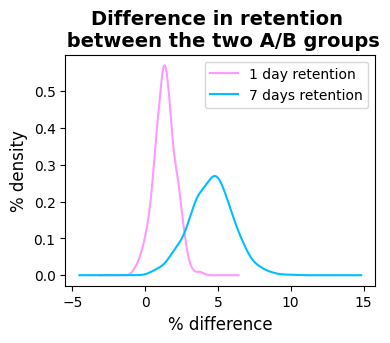

In [20]:
# Adding a column with the % difference between the two A/B groups
boot_1d['diff'] = ((boot_1d['gate_30'] - boot_1d['gate_40']) / boot_1d['gate_40'] * 100)
boot_7d['diff'] = ((boot_7d['gate_30'] - boot_7d['gate_40']) / boot_7d['gate_40'] * 100)

# Ploting the bootstrap % difference
fig, (ax1) = plt.subplots(1, 1,figsize=(4,3))

boot_1d['diff'].plot.kde(ax=ax1, c="#ff99ff", label = "1 day retention")
boot_7d['diff'].plot.kde(ax=ax1, c= "#00bfff", label = "7 days retention")
ax1.set_xlabel("% difference",size=12)
ax1.set_ylabel("% density",size=12)
ax1.set_title("Difference in retention \n between the two A/B groups", fontweight="bold", size=14)
plt.legend()
plt.show()

# 상대적 변화율(%) 확인

### 시각화 3

#### 분홍색 곡선 (1 day retention 차이)

- 봉우리가 **1~2% 부근**에 좁고 뾰족하게 형성되어 있습니다.
- 왼쪽 꼬리가 **0보다 살짝 왼쪽(음수 영역)까지 걸쳐 있습니다** — 곡선이 x=0 근처에서도 완전히 0이 아니라 약간의 밀도를 가지고 있습니다.
- **해석**: 재표본추출 결과 중 일부는 차이가 0 이하(즉 gate_40이 오히려 같거나 높음)로 나올 수 있다는 뜻입니다. 이는 D1 신뢰구간이 0을 포함했던 것과 같은 결론을 다시 보여줍니다 — 차이는 대체로 양수 쪽에 몰려 있지만, **유의미하다고 확신할 만큼 0에서 멀리 떨어져 있지는 않습니다.**

#### 하늘색 곡선 (7 days retention 차이)

- 봉우리가 **4% 부근**으로, 분홍 곡선보다 훨씬 오른쪽(더 큰 차이값)에 위치합니다.
- 분포 전체가 **0보다 오른쪽에서 시작**하며, 0 근처에는 밀도가 거의 없습니다.
- 분홍 곡선보다 **폭이 넓게 퍼져 있어(분산이 큼)** 있지만, 그럼에도 0과는 확실히 떨어져 있습니다.
- **해석**: 재표본을 아무리 반복해도 이 차이가 0 이하로 떨어지는 경우가 사실상 없다는 것을 보여줍니다. D7 신뢰구간이 0을 포함하지 않았던 결과와 정확히 일치하며, 시각적으로 "확실한 차이"라는 인상을 강하게 줍니다.

#### 두 곡선을 함께 보는 것의 의미

| 구분 | 봉우리 위치 | 0과의 거리 | 통계적 함의 |
|---|---|---|---|
| D1 (분홍) | 약 1~2% | 가까움 (일부 0 이하로 겹침) | 유의성 불확실 |
| D7 (하늘색) | 약 4% | 멂 (0과 명확히 분리) | 유의미한 차이 |

즉 **D7이 D1보다 효과 크기(차이의 폭)도 더 크고, 통계적 확실성(0과의 분리 정도)도 더 크다**는 두 가지 사실을 동시에 전달하는 그래프입니다. 이는 앞서 정리한 카이제곱 p-value(D1=0.0715, D7=0.0014) 결과와도 방향이 일치합니다.


In [21]:
# -----------------------------------------------------------
# STEP 6. 결론 요약 출력
# -----------------------------------------------------------
print("\n=== 결론 요약 ===")
print(retention_summary)
print("D1 리텐션: gate_30이 gate_40보다 통계적으로 유의미하게 높은지 위 p-value로 확인")
print("D7 리텐션: 위 검정 결과 및 신뢰구간을 근거로 게이트 위치 제안 작성")



=== 결론 요약 ===
         D1_retention_rate  D7_retention_rate
version                                      
gate_30           0.447704           0.189458
gate_40           0.441713           0.181144
D1 리텐션: gate_30이 gate_40보다 통계적으로 유의미하게 높은지 위 p-value로 확인
D7 리텐션: 위 검정 결과 및 신뢰구간을 근거로 게이트 위치 제안 작성


### 결론
: D7 리텐션 기준으로 gate_30이 gate_40보다 통계적으로 유의미하게 높다 (카이제곱 p=0.0014, 부트스트랩 재표본의 99.8%에서 gate_30이 우위). 반면 D1 리텐션은 통계적으로 유의미한 차이가 확인되지 않았다 (p=0.0715). 따라서 장기 리텐션 관점에서는 게이트를 레벨 30에서 40으로 옮기지 않는 것이 안전한 선택이며, 다만 이 결론은 리텐션 지표에 한정된 것으로, 과금·플레이 라운드 수 등 수익성 지표를 함께 봐야 최종 의사결정이 완전해진다.

**장기 유지율(D7) 저하 위험을 방지하기 위해 게이트 위치를 Level 40으로 이동하지 않고 Level 30으로 유지하는 것을 권장합니다**